# SECOM DATASET - EXPLORATION

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('/Users/prathamtanti5163/Library/CloudStorage/OneDrive-TechnischeHochschuleRosenheim/Seacom_ML_Prediction/seacom_dataset/secom.data', sep=' ', header=None)
labels = pd.read_csv('/Users/prathamtanti5163/Library/CloudStorage/OneDrive-TechnischeHochschuleRosenheim/Seacom_ML_Prediction/seacom_dataset/secom_labels.data', sep=' ', header=None)
labels.columns = ['outcome', 'timestamp']

In [4]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


This cell explains the label encoding used in the dataset: `-1` represents a bad batch, while `+1` represents a good batch.

In [5]:
labels.head()

,outcome,timestamp
0,-1,19/07/2008 11:55:00
1,-1,19/07/2008 12:32:00
2,1,19/07/2008 13:17:00
3,-1,19/07/2008 14:43:00
4,-1,19/07/2008 15:22:00


In [6]:
# Combine into one dataframe
df = data.copy()
df['outcome'] = labels['outcome']

print("✅ Data loaded successfully")


✅ Data loaded successfully


In [7]:
print("\n=== DATASET OVERVIEW ===")
print(f"Total samples:        {len(df)}")
print(f"Total sensors:        {data.shape[1]}")
print(f"Bad batches  (1):     {(df['outcome'] == 1).sum()}")
print(f"Good batches (-1):    {(df['outcome'] == -1).sum()}")
print(f"Bad batch rate:       {(df['outcome'] == 1).mean()*100:.2f}%")


=== DATASET OVERVIEW ===
Total samples:        1567
Total sensors:        590
Bad batches  (1):     104
Good batches (-1):    1463
Bad batch rate:       6.64%


In [8]:
df.columns

Index([        0,         1,         2,         3,         4,         5,
               6,         7,         8,         9,
       ...
             581,       582,       583,       584,       585,       586,
             587,       588,       589, 'outcome'],
      dtype='object', length=591)

# STEP 3 - MISSING VALUES

In [9]:
print("\n=== MISSING VALUES ===")
missing_total = data.isnull().sum().sum()
missing_cols = data.isnull().any().sum()
missing_pct = (missing_total / (data.shape[0] * data.shape[1])) * 100

print(f"Total missing values:     {missing_total}")
print(f"Columns with missing:     {missing_cols} out of {data.shape[1]}")
print(f"Overall missing %:        {missing_pct:.2f}%")


=== MISSING VALUES ===
Total missing values:     41951
Columns with missing:     538 out of 590
Overall missing %:        4.54%


In [15]:
df.dtypes

0          float64
1          float64
2          float64
3          float64
4          float64
            ...   
586        float64
587        float64
588        float64
589        float64
outcome      int64
Length: 591, dtype: object

In [17]:
cols = [157,292,293,294,158]
for col in cols:
    print(f"\n=== SENSOR {col} ===")
    print (f"Missing values: {data[col].isnull().sum()} ({data[col].isnull().mean()*100:.2f}%)")


=== SENSOR 157 ===
Missing values: 1429 (91.19%)

=== SENSOR 292 ===
Missing values: 1429 (91.19%)

=== SENSOR 293 ===
Missing values: 1429 (91.19%)

=== SENSOR 294 ===
Missing values: 2 (0.13%)

=== SENSOR 158 ===
Missing values: 1429 (91.19%)


# STEP 4 - VISUALISE CLASS IMBALANCE

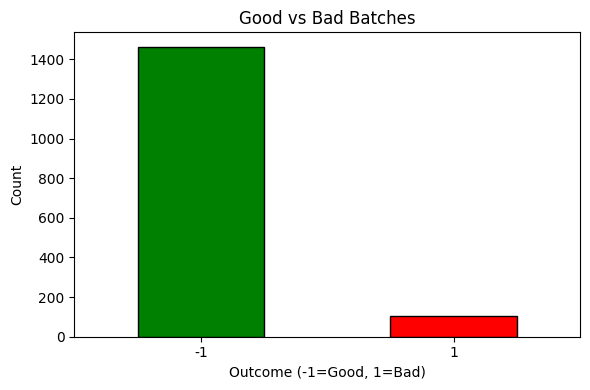

✅ Class imbalance chart saved


In [11]:
plt.figure(figsize=(6,4))
df['outcome'].value_counts().plot(kind='bar', 
                                   color=['green','red'],
                                   edgecolor='black')
plt.title('Good vs Bad Batches')
plt.xlabel('Outcome (-1=Good, 1=Bad)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/class_imbalance.png')
plt.show()
print("✅ Class imbalance chart saved")


In [19]:
class_counts = df['outcome'].value_counts()
ratio = class_counts[-1] / class_counts[1]

print(f"Pass  (-1): {class_counts[-1]}")
print(f"Fail   (1): {class_counts[1]}")
print(f"Imbalance ratio (Pass:Fail) = {ratio:.1f}:1")
print(f"Fail rate = {class_counts[1] / len(df) * 100:.2f}%")

Pass  (-1): 1463
Fail   (1): 104
Imbalance ratio (Pass:Fail) = 14.1:1
Fail rate = 6.64%


# STEP 5 - VISUALISE MISSING VALUES

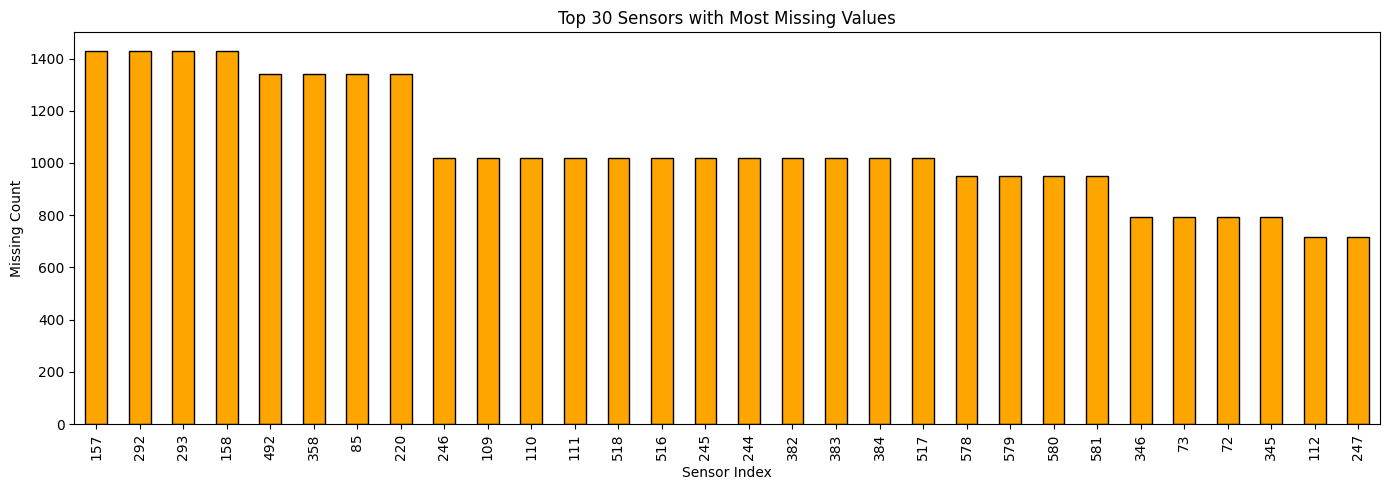

✅ Missing values chart saved


In [12]:
missing_per_col = data.isnull().sum().sort_values(ascending=False)
top_missing = missing_per_col[missing_per_col > 0].head(30)

plt.figure(figsize=(14,5))
top_missing.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 30 Sensors with Most Missing Values')
plt.xlabel('Sensor Index')
plt.ylabel('Missing Count')
plt.tight_layout()
plt.savefig('../reports/figures/missing_values.png')
plt.show()
print("✅ Missing values chart saved")

# STEP 6 - FIRST LOOK AT SENSOR READINGS

In [18]:

print("\n=== SAMPLE SENSOR READINGS (first 5 sensors) ===")
print(df.iloc[:5, :5])

print("\n=== BASIC STATISTICS (first 5 sensors) ===")
print(df.iloc[:, :5].describe().round(2))



=== SAMPLE SENSOR READINGS (first 5 sensors) ===
         0        1          2          3       4
0  3030.93  2564.00  2187.7333  1411.1265  1.3602
1  3095.78  2465.14  2230.4222  1463.6606  0.8294
2  2932.61  2559.94  2186.4111  1698.0172  1.5102
3  2988.72  2479.90  2199.0333   909.7926  1.3204
4  3032.24  2502.87  2233.3667  1326.5200  1.5334

=== BASIC STATISTICS (first 5 sensors) ===
             0        1        2        3        4
count  1561.00  1560.00  1553.00  1553.00  1553.00
mean   3014.45  2495.85  2200.55  1396.38     4.20
std      73.62    80.41    29.51   441.69    56.36
min    2743.24  2158.75  2060.66     0.00     0.68
25%    2966.26  2452.25  2181.04  1081.88     1.02
50%    3011.49  2499.40  2201.07  1285.21     1.32
75%    3056.65  2538.82  2218.06  1591.22     1.53
max    3356.35  2846.44  2315.27  3715.04  1114.54


## 6. Correlation Matrix

> **Note:** Correlation is computed on raw data with missing values.
> Pandas `.corr()` excludes NaN pairs per feature pair (pairwise complete).
> Interpret with caution at this stage.

### 6a. Full Correlation Matrix

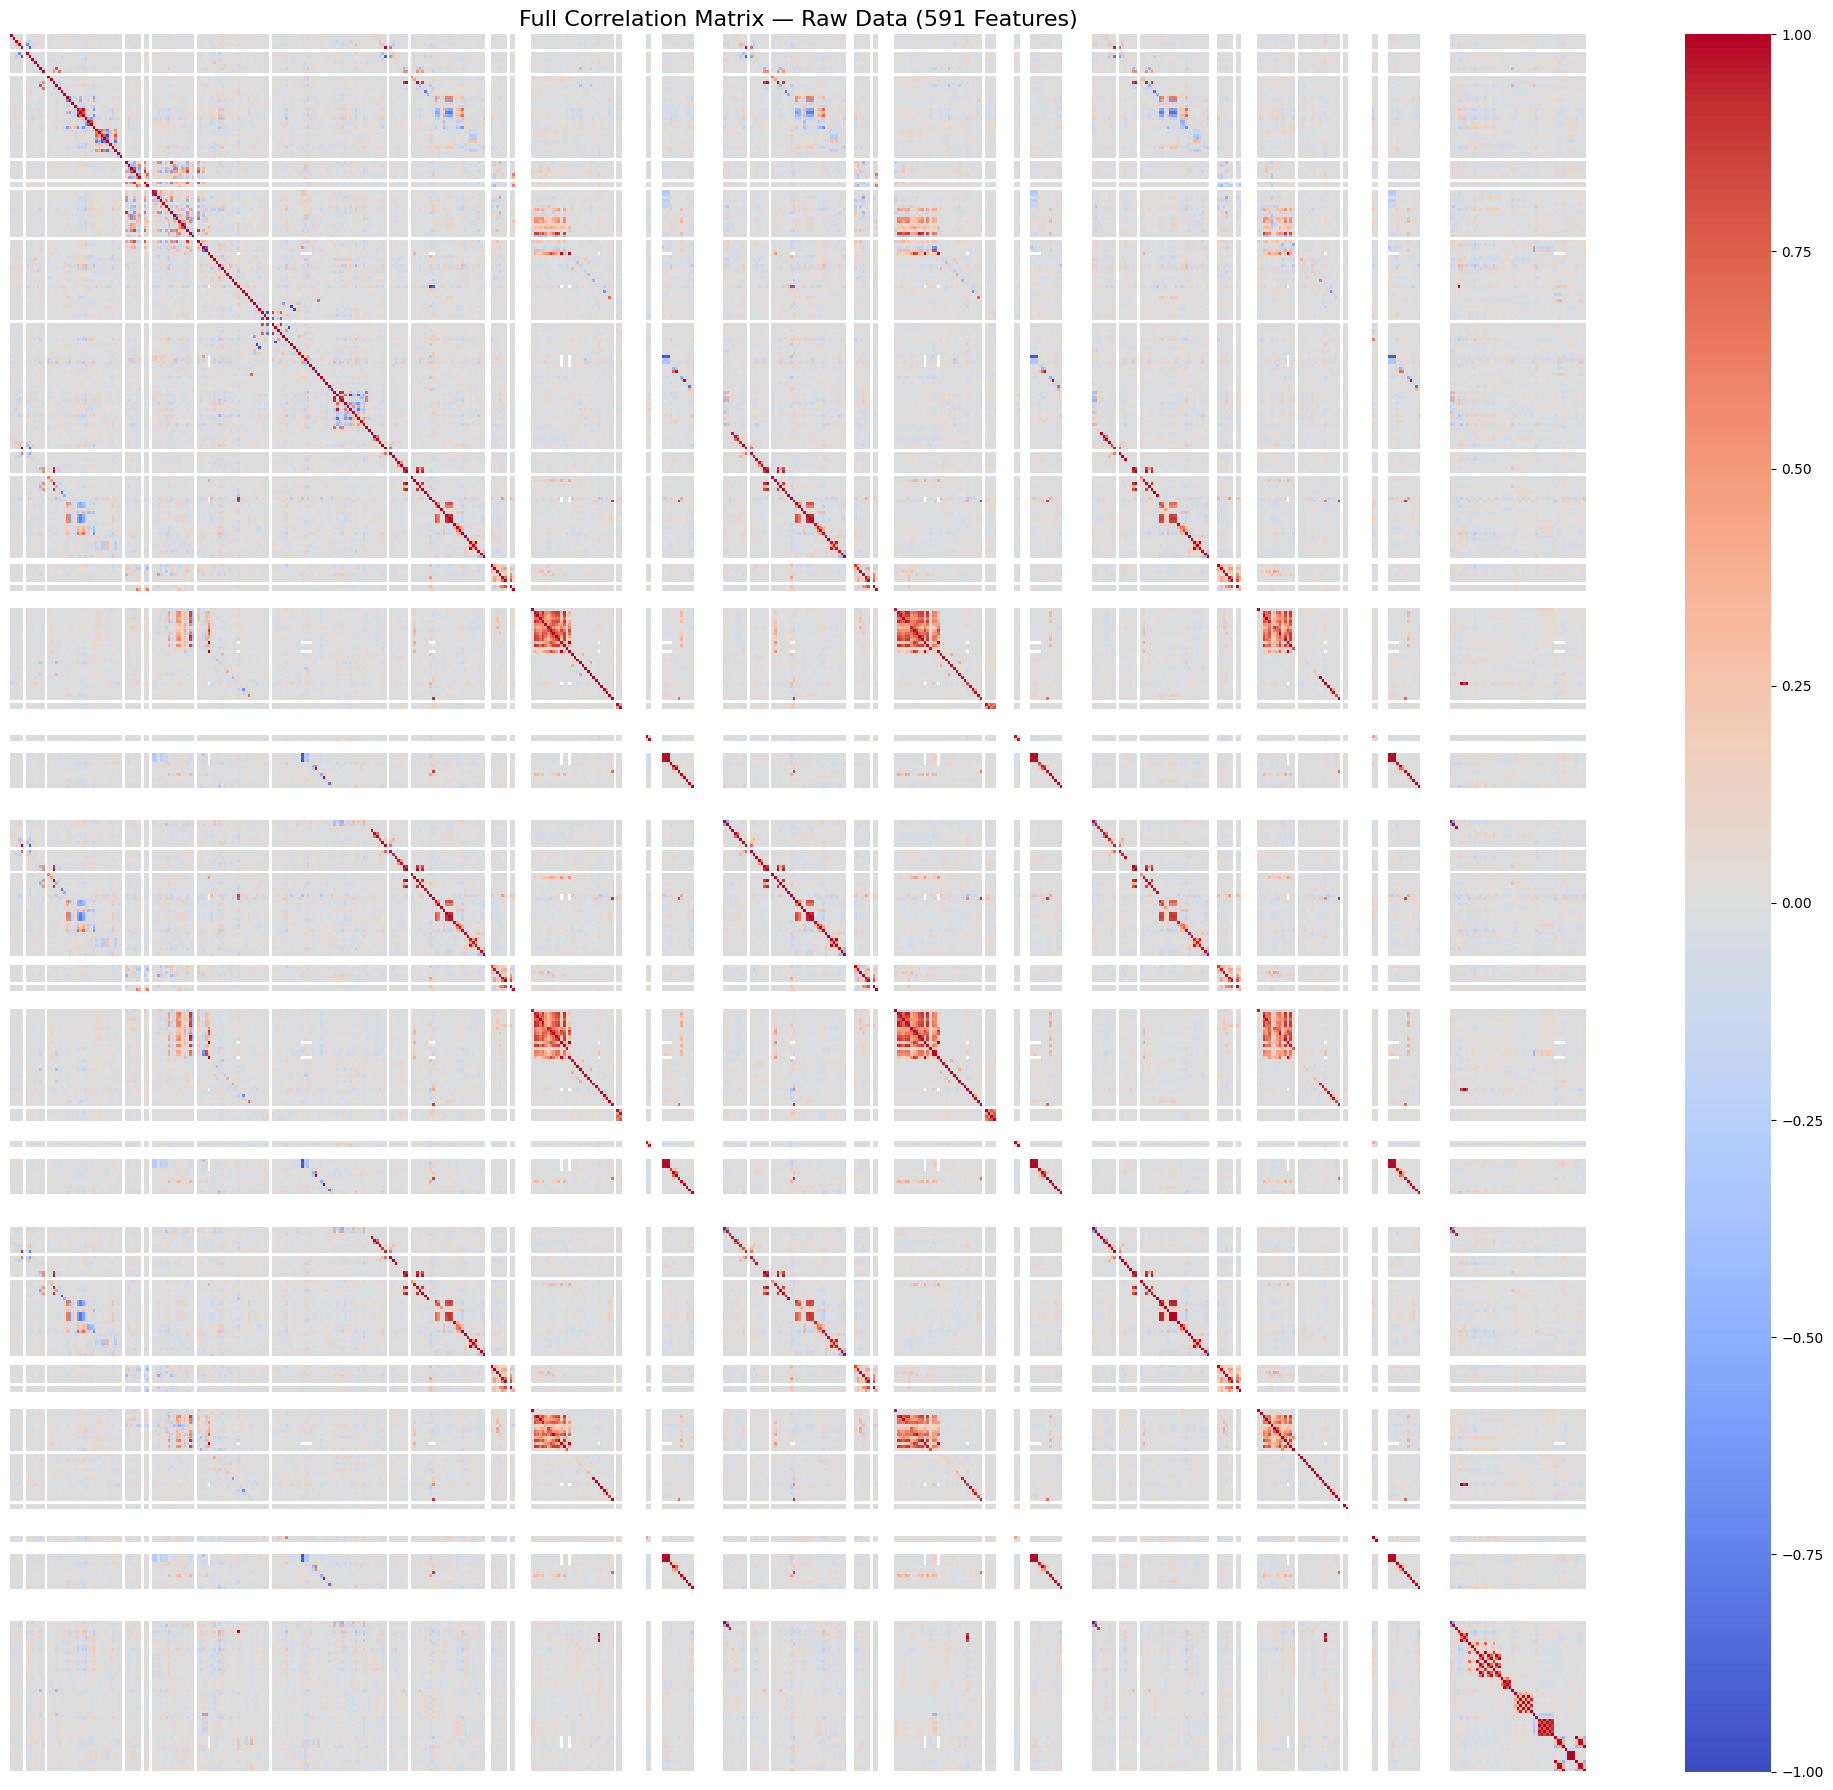

✅ Full correlation matrix saved


In [21]:
corr = df.drop(columns=['outcome']).corr()

plt.figure(figsize=(20, 18))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0,
    xticklabels=False,
    yticklabels=False
)
plt.title('Full Correlation Matrix — Raw Data (591 Features)', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/corr_full.png', dpi=300)  # higher dpi helps
plt.show()
print("✅ Full correlation matrix saved")

 ### 6b. Top 30 Most Variable Features

Focused and readable — picks the 30 features with highest variance.
Reduce N further if still hard to read.

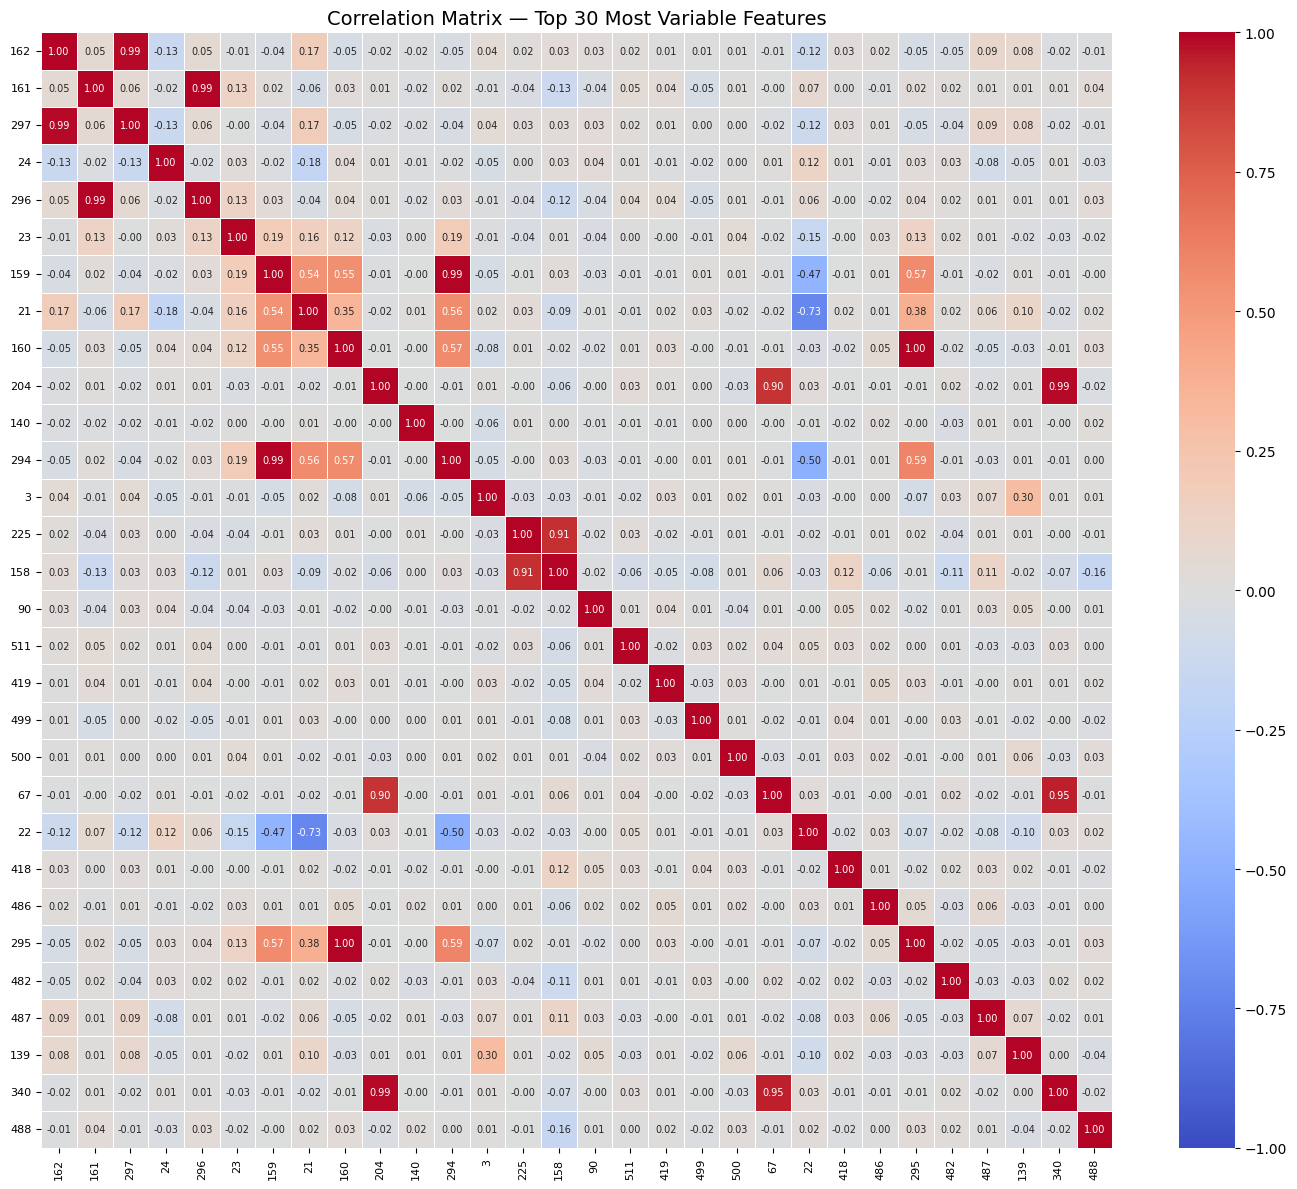

✅ Top 30 correlation matrix saved


In [22]:
N = 30  # lower than 50 — much more readable
top_features = df.drop(columns=['outcome']).var().nlargest(N).index
corr_top = df[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_top,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    annot=True,          # show actual values — readable at N=30
    fmt='.2f',
    annot_kws={'size': 7},
    linewidths=0.5,
    xticklabels=True,
    yticklabels=True
)
plt.title(f'Correlation Matrix — Top {N} Most Variable Features', fontsize=14)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig('../reports/figures/corr_top30.png', dpi=200)
plt.show()
print("✅ Top 30 correlation matrix saved")

### 6c. High Correlation Pairs (> 0.90)

Instead of the visual, we list the strongly correlated feature pairs directly.
This is more actionable than trying to read a 591x591 matrix.

In [23]:
corr = df.drop(columns=['outcome']).corr().abs()

# Upper triangle only to avoid duplicates
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find pairs above threshold
threshold = 0.90
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'})
    .query('Correlation > @threshold')
    .sort_values('Correlation', ascending=False)
    .reset_index(drop=True)
)

print(f"Feature pairs with correlation > {threshold}: {len(high_corr_pairs)}")
high_corr_pairs.head(20)

Feature pairs with correlation > 0.9: 419


,Feature 1,Feature 2,Correlation
0,206,209,1.0
1,209,478,1.0
2,209,347,1.0
3,342,347,1.0
4,74,209,1.0
5,209,342,1.0
6,74,478,1.0
7,74,347,1.0
8,74,342,1.0
9,220,543,1.0
